In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.model_selection import StratifiedKFold, train_test_split
from tqdm import tqdm
from sklearn.metrics import (
    cohen_kappa_score, 
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score
)

In [2]:
# --- CONFIGURATION ---
RAW_IMAGE_PATH = "/kaggle/input/datasets/ejunefong/training-data/Training+Testing_data"
PROCESSED_PATH = "/kaggle/working/processed_images" 
DF_PATH = "/kaggle/input/datasets/ejunefong/training-data/Training+Testing_data_label.csv"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 5
BATCH_SIZE = 16
NUM_EPOCHS = 20

In [3]:
# --- OFFLINE PREPROCESSING SCRIPT ---
def run_offline_preprocessing(df, source_path, dest_path):
    os.makedirs(dest_path, exist_ok=True)
    print("Preprocessing images offline...")
    for img_name in tqdm(df["Image"]):
        save_file = os.path.join(dest_path, img_name)
        if os.path.exists(save_file): continue
        
        img = cv2.imread(os.path.join(source_path, img_name))
        if img is None: continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Crop, Resize, Ben Graham, CLAHE
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray > 5
        if np.any(mask):
            img = img[np.ix_(mask.any(1), mask.any(0))]
        img = cv2.resize(img, (512, 512))
        img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0,0), 10), -4, 128)
        lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        lab[:,:,0] = clahe.apply(lab[:,:,0])
        img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)
        
        cv2.imwrite(save_file, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

In [4]:
# --- DATASET ---
class RetinalDataset(Dataset):
    def __init__(self, df, image_path, transform=None):
        self.df = df
        self.image_path = image_path
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_path, row["Image"])
        image = Image.open(img_path).convert("RGB")
        label = torch.tensor(row["Label"], dtype=torch.long) # ### MODIFIED: Explicit Long type ###
        
        if self.transform:
            image = self.transform(image)
        return image, label

In [5]:
# --- AUGMENTATION ---
train_trans = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(359),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
# --- MODEL ---
def get_model(num_classes=5):
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.4), 
        nn.Linear(in_features, num_classes)
    )
    return model

In [7]:
# --- TRAIN ONE EPOCH ---
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    return running_loss / total, correct / total, epoch_kappa, epoch_f1

# --- VALIDATION FUNCTION ---
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate metrics
    val_kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    val_f1 = f1_score(all_labels, all_preds, average='weighted')
    
    # Return everything: Loss, Accuracy, Kappa (Primary), and F1 (Secondary)
    return running_loss / total, correct / total, val_kappa, val_f1

In [8]:
# --- METRICS FUNCTION ---
def evaluate_model_performance(y_true, y_pred, train_losses=None, val_losses=None, title="Model Performance"):
    classes = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
    
    # Layout Setup 
    # If we have losses, show 2 columns (Loss + Matrix). If not (Ensemble), show 1 column.
    has_history = train_losses is not None and val_losses is not None
    fig_cols = 2 if has_history else 1
    plt.figure(figsize=(8 * fig_cols, 6))
    
    # Plot Loss Curves (Optional) 
    if has_history:
        plt.subplot(1, 2, 1)
        plt.plot(train_losses, label='Train', marker='o', color='#1f77b4')
        plt.plot(val_losses, label='Val', marker='o', color='#d62728')
        plt.title(f'{title} - Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True, alpha=0.3)

    # Plot Confusion Matrix 
    plt.subplot(1, fig_cols, fig_cols)
    cm = confusion_matrix(y_true, y_pred)
    # Normalize by row (actual class) to see recall percentages
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes, cbar=False)
    plt.title(f'{title} - Confusion Matrix')
    plt.ylabel('Actual Stage')
    plt.xlabel('Predicted Stage')
    
    plt.tight_layout()
    plt.show()

    # Calculate & Print Metrics 
    metrics = {
        "Kappa (Quadratic)": cohen_kappa_score(y_true, y_pred, weights='quadratic'),
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred, average='weighted'),
        "Precision": precision_score(y_true, y_pred, average='weighted'),
        "Recall": recall_score(y_true, y_pred, average='weighted')
    }
    
    print(f"\n" + "="*30)
    print(f" {title.upper()} REPORT")
    print("="*30)
    for name, value in metrics.items():
        print(f"{name:20}: {value:.4f}")
    print("="*30 + "\n")

In [9]:
# --- LOAD & SPLIT ---
df = pd.read_csv(DF_PATH)
run_offline_preprocessing(df, RAW_IMAGE_PATH, PROCESSED_PATH)

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Label"], random_state=42)
train_df = train_df.reset_index(drop=True)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_df["Fold"] = -1
for fold, (t_idx, v_idx) in enumerate(skf.split(train_df, train_df["Label"])):
    train_df.loc[v_idx, 'Fold'] = fold

Preprocessing images offline...


 59%|█████▊    | 2897/4939 [03:29<05:55,  5.74it/s]Corrupt JPEG data: 36 extraneous bytes before marker 0xd9
Corrupt JPEG data: 36 extraneous bytes before marker 0xd9
100%|██████████| 4939/4939 [06:07<00:00, 13.46it/s]



STARTING FOLD 1
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 202MB/s]


Epoch 01 | Val Kappa: 0.8106 | Val F1: 0.6874 | Val Acc: 0.7320
--> Saved New Best Kappa: 0.8106
Epoch 02 | Val Kappa: 0.8551 | Val F1: 0.7493 | Val Acc: 0.7560
--> Saved New Best Kappa: 0.8551
Epoch 03 | Val Kappa: 0.8664 | Val F1: 0.7736 | Val Acc: 0.7863
--> Saved New Best Kappa: 0.8664
Epoch 04 | Val Kappa: 0.8505 | Val F1: 0.7713 | Val Acc: 0.7876
--- Patience: 1/3 (Loss did not improve) ---
Epoch 05 | Val Kappa: 0.8853 | Val F1: 0.8009 | Val Acc: 0.8028
--> Saved New Best Kappa: 0.8853
Epoch 06 | Val Kappa: 0.8839 | Val F1: 0.7943 | Val Acc: 0.7939
--- Patience: 1/3 (Loss did not improve) ---
Epoch 07 | Val Kappa: 0.8936 | Val F1: 0.8034 | Val Acc: 0.7927
--> Saved New Best Kappa: 0.8936
Epoch 08 | Val Kappa: 0.8694 | Val F1: 0.7860 | Val Acc: 0.7775
--- Patience: 1/3 (Loss did not improve) ---
Epoch 09 | Val Kappa: 0.8929 | Val F1: 0.7970 | Val Acc: 0.7863
Epoch 10 | Val Kappa: 0.8792 | Val F1: 0.8102 | Val Acc: 0.8129
--- Patience: 1/3 (Loss did not improve) ---
Epoch 11 | Val 

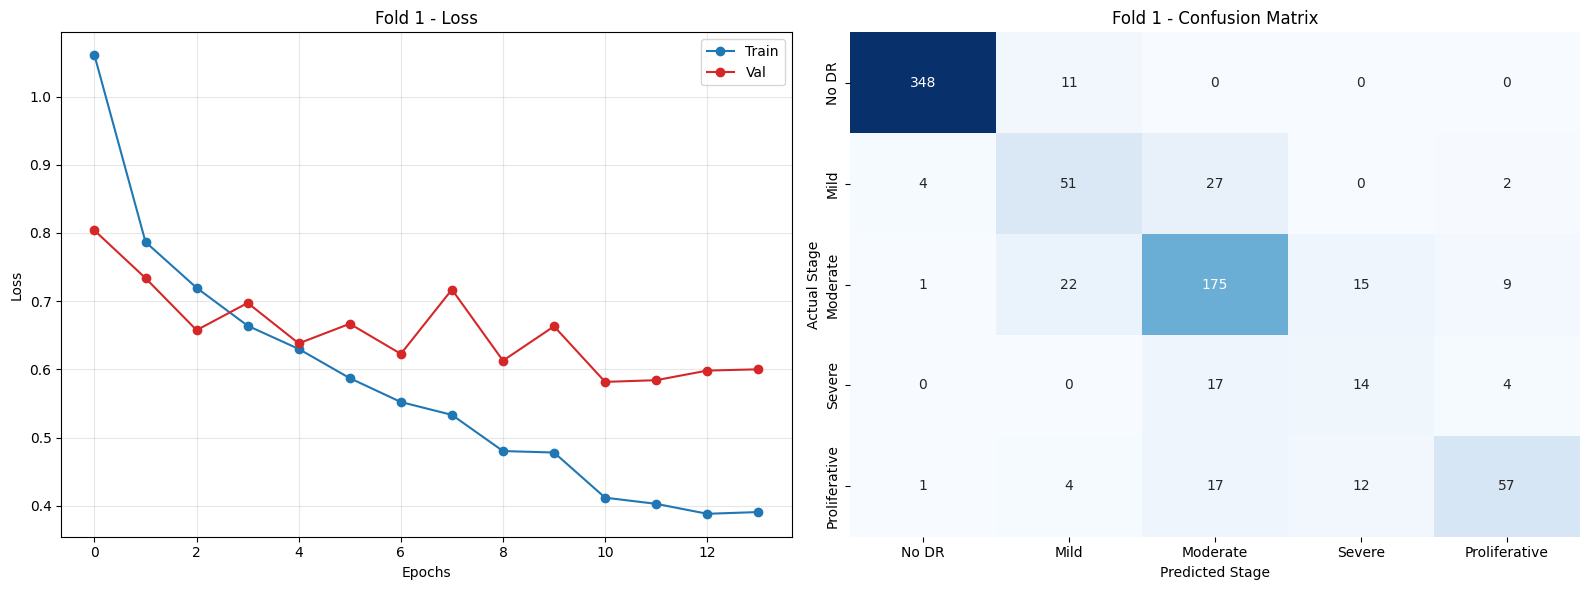


 FOLD 1 REPORT
Kappa (Quadratic)   : 0.8982
Accuracy            : 0.8154
F1 Score            : 0.8172
Precision           : 0.8220
Recall              : 0.8154


STARTING FOLD 2
Epoch 01 | Val Kappa: 0.8347 | Val F1: 0.7239 | Val Acc: 0.7468
--> Saved New Best Kappa: 0.8347
Epoch 02 | Val Kappa: 0.8774 | Val F1: 0.7659 | Val Acc: 0.7759
--> Saved New Best Kappa: 0.8774
Epoch 03 | Val Kappa: 0.8839 | Val F1: 0.7718 | Val Acc: 0.7671
--> Saved New Best Kappa: 0.8839
Epoch 04 | Val Kappa: 0.8709 | Val F1: 0.7797 | Val Acc: 0.7899
Epoch 05 | Val Kappa: 0.8735 | Val F1: 0.7835 | Val Acc: 0.7835
Epoch 06 | Val Kappa: 0.8848 | Val F1: 0.7927 | Val Acc: 0.7886
--> Saved New Best Kappa: 0.8848
Epoch 07 | Val Kappa: 0.8971 | Val F1: 0.8080 | Val Acc: 0.8000
--> Saved New Best Kappa: 0.8971
Epoch 08 | Val Kappa: 0.9112 | Val F1: 0.8276 | Val Acc: 0.8253
--> Saved New Best Kappa: 0.9112
Epoch 09 | Val Kappa: 0.9088 | Val F1: 0.8309 | Val Acc: 0.8291
--- Patience: 1/3 (Loss did not improve) ---
Ep

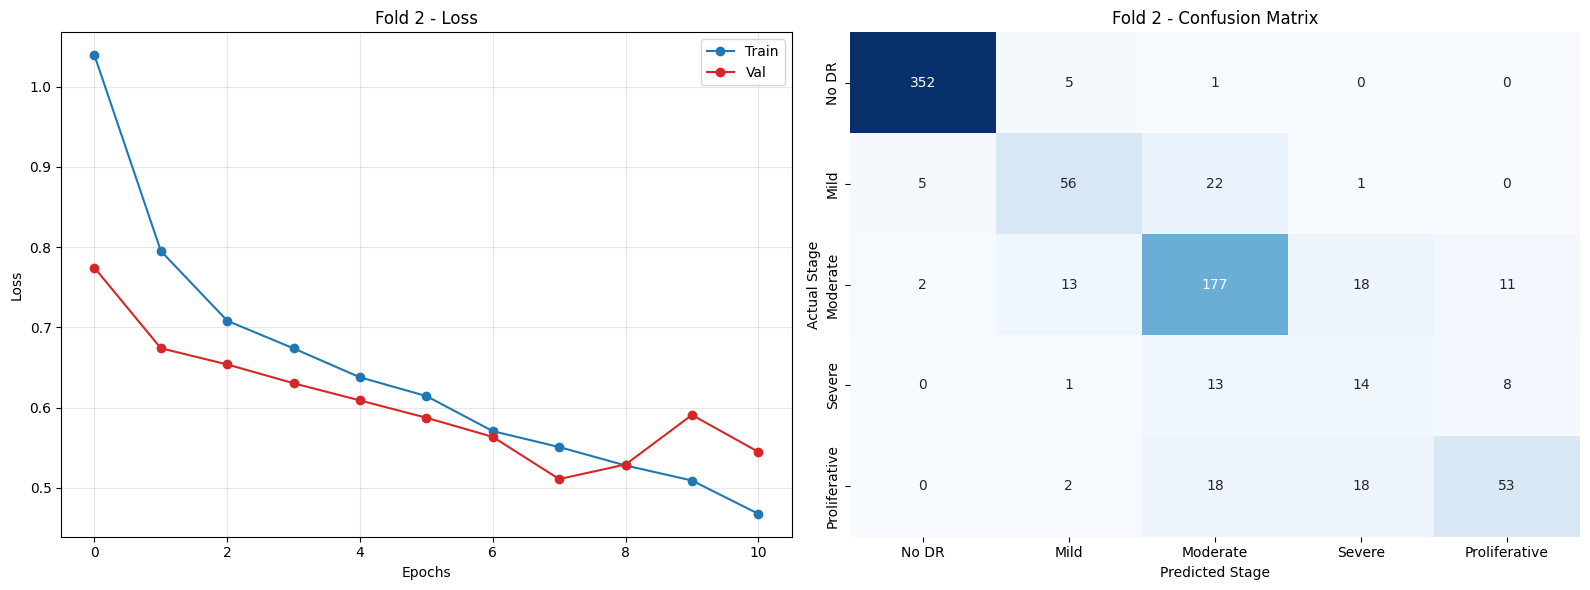


 FOLD 2 REPORT
Kappa (Quadratic)   : 0.9112
Accuracy            : 0.8253
F1 Score            : 0.8276
Precision           : 0.8333
Recall              : 0.8253


STARTING FOLD 3
Epoch 01 | Val Kappa: 0.8300 | Val F1: 0.7460 | Val Acc: 0.7532
--> Saved New Best Kappa: 0.8300
Epoch 02 | Val Kappa: 0.8346 | Val F1: 0.7648 | Val Acc: 0.7671
--> Saved New Best Kappa: 0.8346
Epoch 03 | Val Kappa: 0.8575 | Val F1: 0.7866 | Val Acc: 0.7873
--> Saved New Best Kappa: 0.8575
Epoch 04 | Val Kappa: 0.8678 | Val F1: 0.8028 | Val Acc: 0.8101
--> Saved New Best Kappa: 0.8678
--- Patience: 1/3 (Loss did not improve) ---
Epoch 05 | Val Kappa: 0.8663 | Val F1: 0.7944 | Val Acc: 0.7937
Epoch 06 | Val Kappa: 0.8477 | Val F1: 0.7611 | Val Acc: 0.7456
--- Patience: 1/3 (Loss did not improve) ---
Epoch 07 | Val Kappa: 0.8686 | Val F1: 0.7948 | Val Acc: 0.7937
--> Saved New Best Kappa: 0.8686
Epoch 08 | Val Kappa: 0.8728 | Val F1: 0.8069 | Val Acc: 0.8101
--> Saved New Best Kappa: 0.8728
Epoch 09 | Val Kappa:

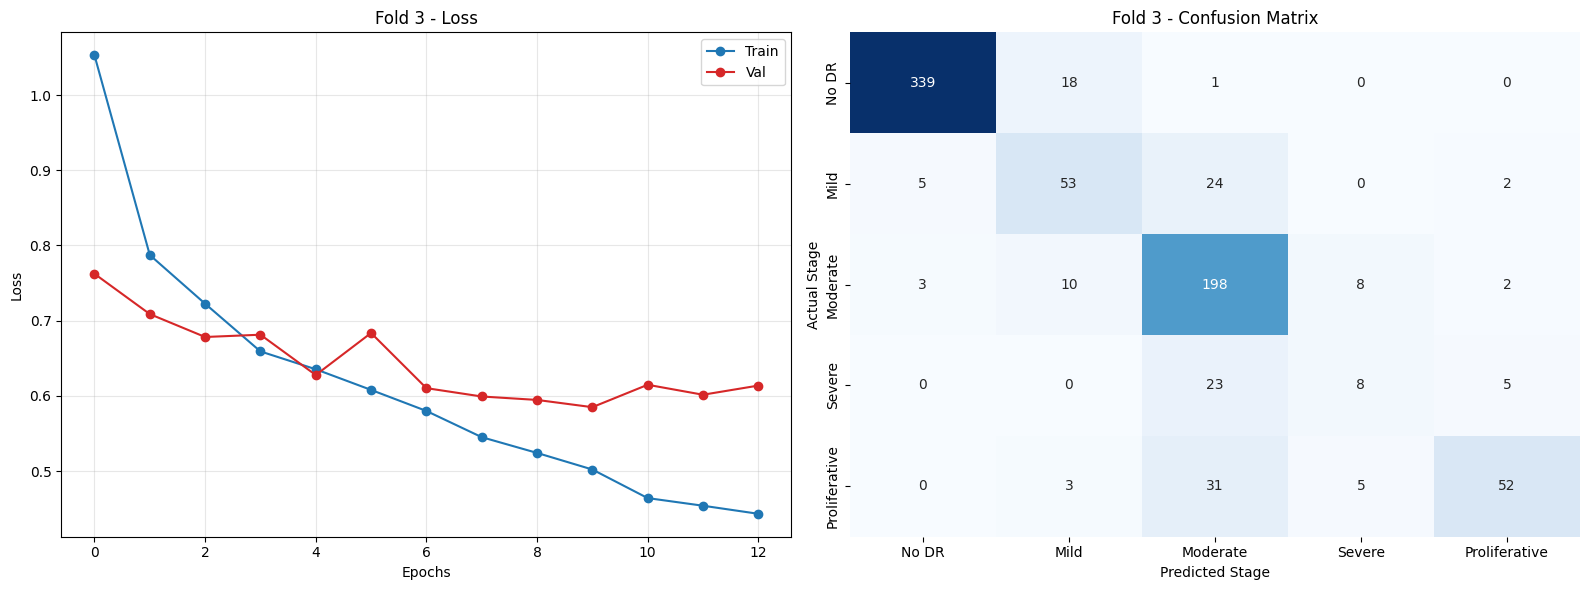


 FOLD 3 REPORT
Kappa (Quadratic)   : 0.8929
Accuracy            : 0.8228
F1 Score            : 0.8170
Precision           : 0.8253
Recall              : 0.8228


STARTING FOLD 4
Epoch 01 | Val Kappa: 0.8337 | Val F1: 0.7227 | Val Acc: 0.7329
--> Saved New Best Kappa: 0.8337
Epoch 02 | Val Kappa: 0.8603 | Val F1: 0.7545 | Val Acc: 0.7519
--> Saved New Best Kappa: 0.8603
Epoch 03 | Val Kappa: 0.8792 | Val F1: 0.7680 | Val Acc: 0.7570
--> Saved New Best Kappa: 0.8792
Epoch 04 | Val Kappa: 0.8985 | Val F1: 0.7809 | Val Acc: 0.7709
--> Saved New Best Kappa: 0.8985
Epoch 05 | Val Kappa: 0.8931 | Val F1: 0.7902 | Val Acc: 0.7835
--- Patience: 1/3 (Loss did not improve) ---
Epoch 06 | Val Kappa: 0.8858 | Val F1: 0.7853 | Val Acc: 0.7772
Epoch 07 | Val Kappa: 0.8468 | Val F1: 0.7614 | Val Acc: 0.7608
--- Patience: 1/3 (Loss did not improve) ---
Epoch 08 | Val Kappa: 0.9192 | Val F1: 0.8301 | Val Acc: 0.8266
--> Saved New Best Kappa: 0.9192
Epoch 09 | Val Kappa: 0.9059 | Val F1: 0.8161 | Val Ac

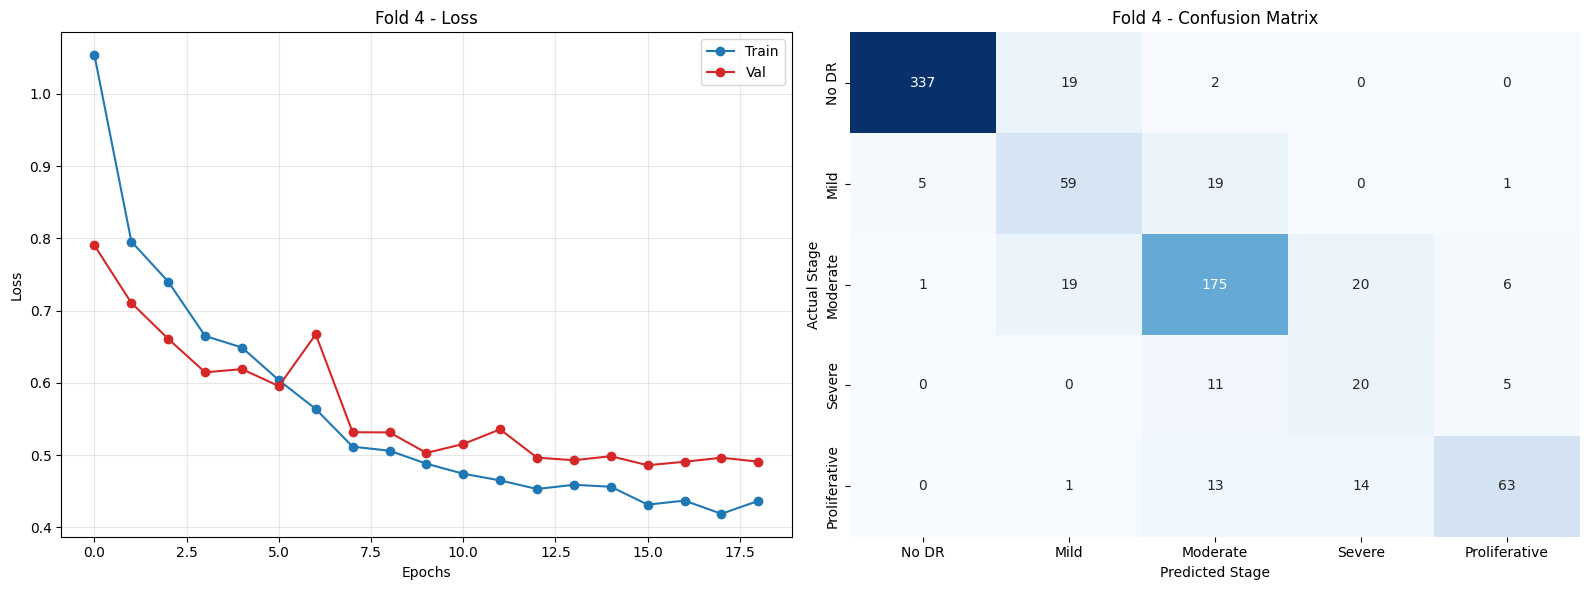


 FOLD 4 REPORT
Kappa (Quadratic)   : 0.9244
Accuracy            : 0.8278
F1 Score            : 0.8344
Precision           : 0.8454
Recall              : 0.8278


STARTING FOLD 5
Epoch 01 | Val Kappa: 0.8177 | Val F1: 0.7339 | Val Acc: 0.7582
--> Saved New Best Kappa: 0.8177
Epoch 02 | Val Kappa: 0.8792 | Val F1: 0.8074 | Val Acc: 0.8152
--> Saved New Best Kappa: 0.8792
Epoch 03 | Val Kappa: 0.8888 | Val F1: 0.7982 | Val Acc: 0.7924
--> Saved New Best Kappa: 0.8888
Epoch 04 | Val Kappa: 0.8950 | Val F1: 0.8106 | Val Acc: 0.8165
--> Saved New Best Kappa: 0.8950
Epoch 05 | Val Kappa: 0.9037 | Val F1: 0.8198 | Val Acc: 0.8228
--> Saved New Best Kappa: 0.9037
Epoch 06 | Val Kappa: 0.9088 | Val F1: 0.8310 | Val Acc: 0.8316
--> Saved New Best Kappa: 0.9088
Epoch 07 | Val Kappa: 0.9134 | Val F1: 0.8395 | Val Acc: 0.8443
--> Saved New Best Kappa: 0.9134
--- Patience: 1/3 (Loss did not improve) ---
Epoch 08 | Val Kappa: 0.9055 | Val F1: 0.8236 | Val Acc: 0.8215
--- Patience: 2/3 (Loss did not i

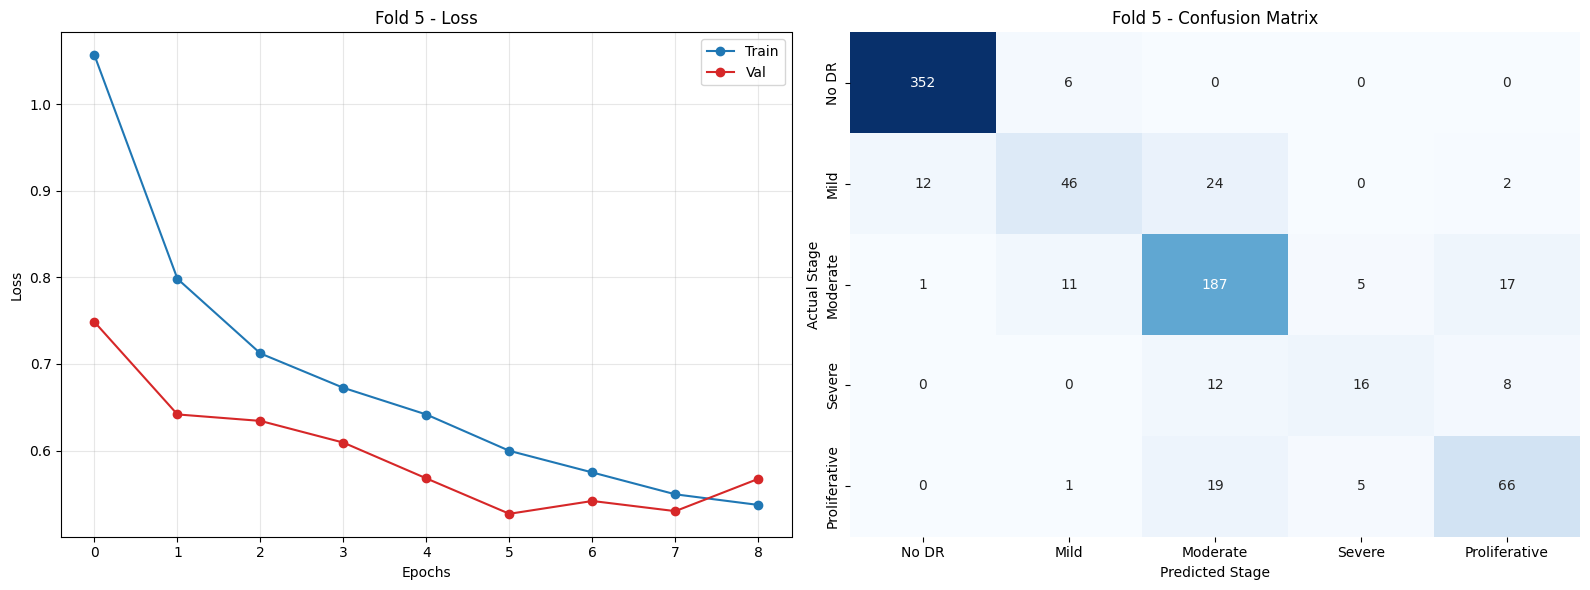


 FOLD 5 REPORT
Kappa (Quadratic)   : 0.9134
Accuracy            : 0.8443
F1 Score            : 0.8395
Precision           : 0.8394
Recall              : 0.8443


All Folds Complete. Mean Kappa: 0.9080


In [10]:
# --- K-FOLD LOOP ---
fold_results = []

for fold in range(5):
    print(f"\nSTARTING FOLD {fold+1}")
    f_train = train_df[train_df['Fold'] != fold].reset_index(drop=True)
    f_val = train_df[train_df['Fold'] == fold].reset_index(drop=True)

    train_loader = DataLoader(RetinalDataset(f_train, PROCESSED_PATH, train_trans), batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
    val_loader = DataLoader(RetinalDataset(f_val, PROCESSED_PATH, val_trans), batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

    model = get_model(NUM_CLASSES).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.2, patience=2)

    class_counts = f_train['Label'].value_counts().sort_index().values
    total_samples = len(f_train)
    beta = 0.997  # Updated to be more aggressive
    
    weights = (1.0 - beta) / (1.0 - np.power(beta, class_counts))
    weights = weights / weights.mean()
    weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
    
    criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.00)

    patience = 3 # Number of epochs to wait after loss starts rising
    patience_counter = 0
    best_val_loss = float('inf')
    
    fold_train_losses = [] 
    fold_val_losses = []
    best_kappa = -1.0 
    
    for epoch in range(NUM_EPOCHS):
        t_loss, t_acc, t_kappa, t_f1 = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        v_loss, v_acc, v_kappa, v_f1 = validate(model, val_loader, criterion, DEVICE)

        fold_train_losses.append(t_loss)
        fold_val_losses.append(v_loss)
        
        scheduler.step(v_kappa)
        
        print(f"Epoch {epoch+1:02d} | Val Kappa: {v_kappa:.4f} | Val F1: {v_f1:.4f} | Val Acc: {v_acc:.4f}")

        if v_kappa > best_kappa:
            best_kappa = v_kappa
            torch.save(model.state_dict(), f"best_model_fold{fold}.pth")
            print(f"--> Saved New Best Kappa: {best_kappa:.4f}")
    
        # EARLY STOPPING LOGIC 
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            patience_counter = 0 
        else:
            patience_counter += 1
            print(f"--- Patience: {patience_counter}/{patience} (Loss did not improve) ---")
    
        if patience_counter >= patience:
            print(f"EARLY STOPPING triggered at epoch {epoch+1}. Preventing overfitting.")
            break
    
    # --- Evaluation Block for this Fold ---
    print(f"\nEvaluating Best Model for Fold {fold+1}...")
    
    model.load_state_dict(torch.load(f"best_model_fold{fold}.pth"))
    model.eval()
    
    y_true_fold = []
    y_pred_fold = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(DEVICE)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            
            y_true_fold.extend(labels.cpu().numpy())
            y_pred_fold.extend(preds.cpu().numpy())
    
    evaluate_model_performance(
        y_true=np.array(y_true_fold), 
        y_pred=np.array(y_pred_fold), 
        train_losses=fold_train_losses, 
        val_losses=fold_val_losses, 
        title=f"Fold {fold+1}"
    )
    
    fold_results.append(best_kappa)

print(f"\nAll Folds Complete. Mean Kappa: {np.mean(fold_results):.4f}")

Evaluating Ensemble: 100%|██████████| 31/31 [01:14<00:00,  2.41s/it]


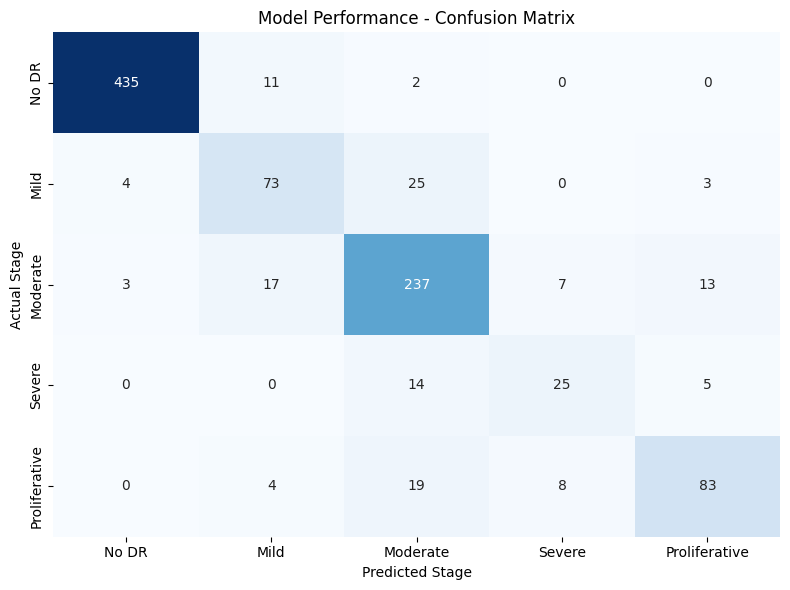


 MODEL PERFORMANCE REPORT
Kappa (Quadratic)   : 0.9169
Accuracy            : 0.8634
F1 Score            : 0.8630
Precision           : 0.8638
Recall              : 0.8634



In [11]:
def evaluate_ensemble(models, test_loader, device):
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc="Evaluating Ensemble"):
            inputs = inputs.to(device)
            ensemble_logits = torch.zeros((inputs.size(0), 5)).to(device)
            
            for model in models:
                model.eval()
                outputs = model(inputs)
                ensemble_logits += torch.softmax(outputs, dim=1)
            
            _, predicted = ensemble_logits.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    acc = (np.array(all_preds) == np.array(all_labels)).mean()
    
    return all_labels, all_preds

# Load models and run
best_models = []
for i in range(5):
    m = get_model(num_classes=5).to(DEVICE)
    m.load_state_dict(torch.load(f"best_model_fold{i}.pth"))
    best_models.append(m)

test_dataset = RetinalDataset(test_df, PROCESSED_PATH, transform=val_trans)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

y_true, y_pred = evaluate_ensemble(best_models, test_loader, DEVICE)

evaluate_model_performance(y_true, y_pred)